# Processing of a market smile

### Numerical processing of financial data

Stefano De Marco

#### Objective
The goal of this notebook is to evaluate the implied volatility from the market quotes for option prices on a stock index (the SP500).

In a second notebook, we will fit a parametric model to this data - specifically designed to reproduce the typical shapes of market implied volatilities on Equity indices.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Part 1. Processing of a market implied volatility smile

Delayed option quotes on the SP500 index can be downloaded freely from the the [CBOE quotes platform](http://www.cboe.com/delayedquote/quote-table)  (index symbol: SPX).

The file *SPX_quotedata.csv* contains the option quotes dowloaded from the platform above, for observation date = Mon Jan 29 2024, and expiration date = Fri Feb 16 2024.

We could load the data into a Pandas dataframe, but since the data structure is simple, the _loadtxt_ function of the _numpy_ library will be enough for our purposes---this is what we use in the cell below.

The current time for our operations is the options' observation date, for which we set $t = 0$.

In [2]:
quotes = np.loadtxt(open("SPX_quotedata.csv", "r"), delimiter=";", skiprows=5)

# Have a look at the columns of the data file so to understand the variables below
strikes = quotes[:, 8]

call_bid = quotes[:, 2]
call_ask = quotes[:, 3]

put_bid = quotes[:, 11]
put_ask = quotes[:, 12]

# Evaluate the call and put mid prices that we 
# will use as reference prices
call_prices = (call_bid + call_ask) / 2
put_prices = (put_bid + put_ask) / 2

# Observation date: Jan 29, 2024
# Expiration Date : Fri Feb 16, 2024
# ---> time to maturity = 18 days
maturity = 18/365

print("quotes.shape :", quotes.shape)
print("\n Strikes: ", strikes)
print("Call prices: ", call_prices)
print("Put prices: ", put_prices, "\n")

print("Maturity (in years): %1.3f" %maturity)

quotes.shape : (199, 17)

 Strikes:  [3750. 3775. 3800. 3825. 3850. 3870. 3875. 3900. 3925. 3950. 3960. 3975.
 3980. 3985. 4000. 4010. 4025. 4040. 4070. 4080. 4090. 4100. 4105. 4115.
 4130. 4135. 4140. 4150. 4160. 4165. 4175. 4185. 4200. 4205. 4215. 4220.
 4225. 4230. 4240. 4245. 4250. 4255. 4270. 4275. 4280. 4290. 4295. 4300.
 4305. 4310. 4320. 4335. 4345. 4350. 4365. 4375. 4380. 4390. 4395. 4400.
 4410. 4415. 4420. 4425. 4430. 4450. 4455. 4460. 4465. 4470. 4475. 4480.
 4490. 4495. 4500. 4510. 4520. 4525. 4530. 4540. 4545. 4550. 4560. 4570.
 4575. 4585. 4590. 4595. 4600. 4605. 4610. 4615. 4620. 4625. 4630. 4635.
 4640. 4645. 4650. 4655. 4660. 4665. 4670. 4675. 4680. 4685. 4690. 4695.
 4700. 4705. 4710. 4715. 4720. 4725. 4730. 4735. 4740. 4745. 4750. 4755.
 4760. 4765. 4770. 4775. 4780. 4785. 4790. 4795. 4800. 4805. 4810. 4815.
 4820. 4825. 4830. 4835. 4840. 4845. 4850. 4855. 4860. 4865. 4870. 4875.
 4880. 4885. 4890. 4895. 4900. 4905. 4910. 4915. 4920. 4925. 4930. 4935.
 4940. 4945. 4

$\blacktriangleright$ Let us have a look at the price quotes

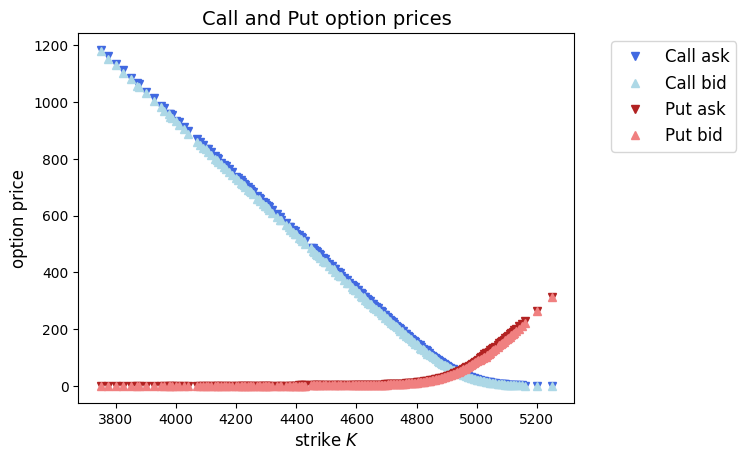

In [3]:
plt.plot(strikes, call_ask, color='royalblue', linewidth=0., marker="v", label="Call ask")
plt.plot(strikes, call_bid, color='lightblue', linewidth=0., marker="^", label="Call bid")

plt.plot(strikes, put_ask, color='firebrick', linewidth=0., marker="v", label="Put ask")
plt.plot(strikes, put_bid, color='lightcoral', linewidth=0., marker="^", label="Put bid")

plt.xlabel("strike $K$", fontsize=12)
plt.ylabel("option price", fontsize=12)
plt.title("Call and Put option prices", fontsize=14)

plt.legend(loc=9, fontsize=12, bbox_to_anchor=(1.2, 1.0), ncol=1)
plt.show()

$\blacktriangleright$ Have a closer look at the strikes between 4600 and 5200.

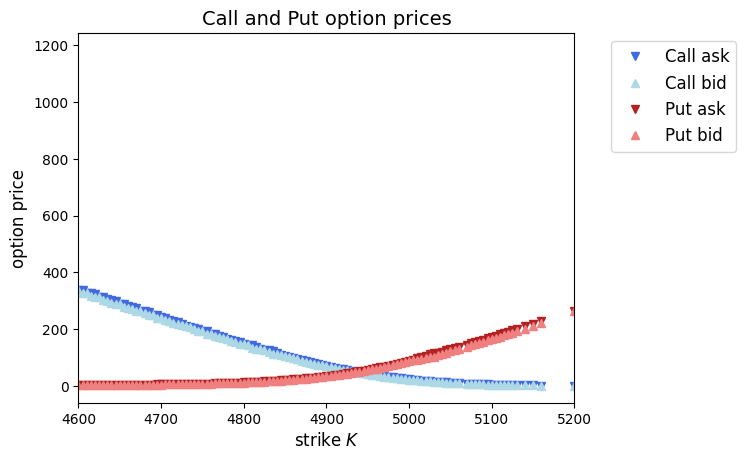

In [4]:
plt.plot(
    strikes, call_ask, color="royalblue", linewidth=0.0, marker="v", label="Call ask"
)
plt.plot(
    strikes, call_bid, color="lightblue", linewidth=0.0, marker="^", label="Call bid"
)

plt.plot(
    strikes, put_ask, color="firebrick", linewidth=0.0, marker="v", label="Put ask"
)
plt.plot(
    strikes, put_bid, color="lightcoral", linewidth=0.0, marker="^", label="Put bid"
)

plt.xlabel("strike $K$", fontsize=12)
plt.ylabel("option price", fontsize=12)
plt.title("Call and Put option prices", fontsize=14)
plt.xlim(4_600, 5_200)

plt.legend(loc=9, fontsize=12, bbox_to_anchor=(1.2, 1.0), ncol=1)
plt.show()

#### $\blacktriangleright$ Now: we test put-call parity, and determine the discount factor $D(0,T)$ and the forward value $F_0^T$ from option quotes

#### $\blacktriangleright$ How to ? Using the theoretical parity relation for call and put prices.

All call and put prices without arbitrage have to satisfy the put-call parity relationship:

$$
\mathrm{Call}(T, K) - \mathrm{Put}(T, K) = D(0,T) F_0^T - D(0,T) K,
\qquad \forall \, K.
$$

where $F_0^T$ is the forward price of the underlying and $D(0,T) = e^{-r T}$ the discount factor.

Note that the property above implies that the function $\mathrm{Call} - \mathrm{Put}$ is a _linear_ function of the strike $K$, independent of the implied volatility of the options involved.

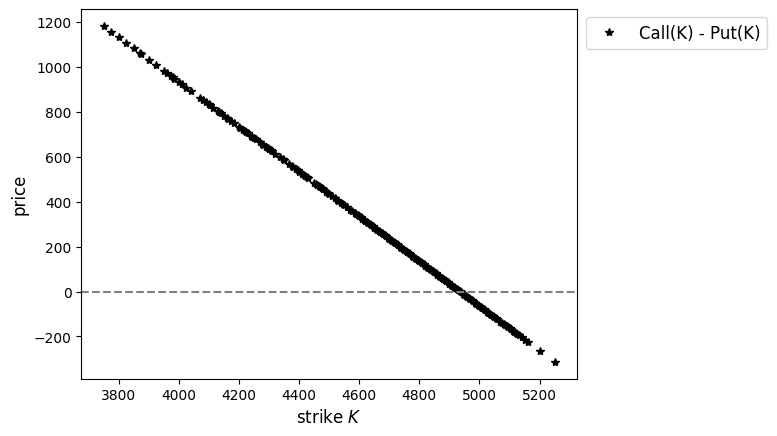

In [6]:
# Done.
call_minus_put = call_prices - put_prices

plt.plot(strikes, call_minus_put, color='black', linewidth=0., marker="*", label="Call(K) - Put(K)")

plt.xlabel(r"strike $K$", fontsize=12)
plt.ylabel("price", fontsize=12)
plt.axhline(0, color='grey', linestyle="--")

plt.legend(loc=9, fontsize=12, bbox_to_anchor=(1.2, 1.0), ncol=1)

#### $\blacktriangleright$ TO DO: perform a linear regression so to determine the discount factor and the forward value

We determine the slope $b$ and the intercept $a$ of the linear function that best interpolates the values of $\mathrm{Call}(K) - \mathrm{Put}(K)$:

$$
\mathrm{Call}(K) - \mathrm{Put}(K) \approx f(K) = a + b \, K.
$$

This gives a way of setting the discount factor and the forward for the maturity $T$ we are working with:

$$
D(0,T) = ???
\qquad
F_0^T = ??? \qquad \text{(in terms of $a$ and $b$)}
$$

In [7]:
import scipy.stats as sps

In [ ]:
# Done.
(slope, intercept, rvalue, other_value1, other_value2) = sps.linregress(strikes, call_minus_put)

print("Slope = %1.3f" %slope)
print("Intercept =: %1.2f" %intercept)
print("R coefficient = %1.12f \n" %rvalue)

# Done.
discount_factor = -slope  # type: ignore

F_T = intercept / discount_factor  # type: ignore

print("Therefore: \n")
print("D(0,T) = %1.3f" %discount_factor)
print("Forward value F_T = %1.2f" %F_T)

Slope = -0.997
Intercept =: 4920.10
R coefficient = -0.999999956531 

Therefore: 

D(0,T) = 0.997
Forward value F_T = 4935.69


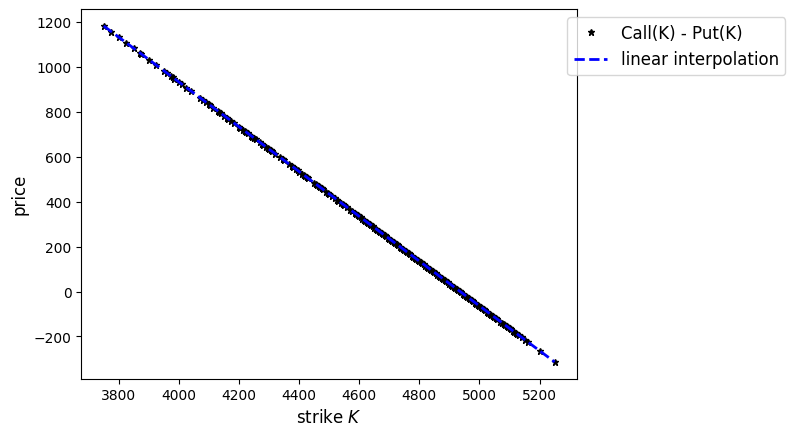

In [10]:
##############################################
# Let us plot the result of linear regression
##############################################
plt.plot(strikes, call_minus_put, color='black', linewidth=0., marker="*", markersize=5, label="Call(K) - Put(K)")
plt.plot(strikes, intercept + slope * strikes, color='blue', linestyle ="--", linewidth=2, label="linear interpolation")  # type: ignore

plt.xlabel(r"strike $K$", fontsize=12)
plt.ylabel("price", fontsize=12)

plt.legend(loc=9, fontsize=12, bbox_to_anchor=(1.2, 1.0), ncol=1)

#### $\blacktriangleright$ TO DO: evaluate the implied volatility generated by the option quotes.

We are now in a good position to evaluate the implied volatility associated to the option prices. 

Recall that the market implied volatility $ \sigma(T,K)$ for maturity $T$ and strike $K$ is the unique solution to the equation

$$
Call^{\mathrm{mkt}}(T,K) = Call_{\mathrm{BS}}(T, K, F_0^T, D(0,T), \sigma(T,K)),
$$

where $Call_{\mathrm{BS}}(T, K, F, D, \sigma)$ is the Black-Scholes call price for maturity $T$, strike $K$, forward value $F$, discount factor $D=e^{-rT}$ and volatility parameter $\sigma$.

_Note_ that we can define the implied volatility from call prices or from the related put prices (as done in the lectures). The two definitions coincide, thanks to the put-call parity relation. 
We can check numerically that the two implied volatilities from calls and from puts coincide on market quotes.

__Implied volatility computation.__
We import an implied volatility solver, *volImplCore_Newton* from the python file 'BlackScholesFunctions.py', which precisely contains the functions we have implemented in the previous notebook.

NOTE: the function *volImplCore_Newton* in the file BlackScholesFunctions.py can evaluate the implied volatility of a call or a put price, according to the value of the argument CallOrPutFlag : set CallOrPutFlag=1 for calls and CallOrPutFlag=0 for puts.

In [12]:
from BlackScholesFunctions import Put_BS_core, volImplCore_Newton, volImplPutCore_bisection, volImplCallCore_bisection

$\blacktriangleright$ __A preliminary test__: First of all, let us test how this solver works.

We evaluate a Black Scholes put option price, and then use the solver to back out the implied volatility parameter used as an input.

In [13]:
sigma_test = 0.35 

K = F_T
F = F_T
DF = discount_factor
tau = maturity

test_put_price = Put_BS_core(tau, K, DF, F, sigma = sigma_test)

print("test put price : %1.3f" %test_put_price)

test put price : 152.522


Let us check that we do back out the implied volatility parameter we used as an input.

In [14]:
######################################
# Implied vol search : Newton method
######################################
vol, iterations = volImplCore_Newton(tau = tau, K = K, DF = DF, F = F_T,
                                     price = test_put_price,
                                     CallOrPutFlag = 1,
                                     initial_point = 0.2, price_tol = 1.e-4, max_iter = 50)

print("Newton search: implied vol=%1.4f, iterations=%1.1f" %(vol, iterations))

##########################################
# Implied vol search : Bisection method
##########################################
vol, iterations = volImplPutCore_bisection(tau = tau, K = K, DF = DF, F = F_T, 
                                            price = test_put_price, 
                                            price_tol = 1.e-2, max_iter = 50, a = 0.001, b = 2.)  # type: ignore

print("Bisection method: implied vol=%1.4f, iterations=%1.1f" %(vol, iterations))

Newton search: implied vol=0.3500, iterations=2.0
Bisection method: implied vol=0.3500, iterations=14.0


$\blacktriangleright$ Let us now move to the implied volatilities of the market call and put prices.

In [ ]:
###########################
## Implied vol from puts
###########################
vols_puts = np.zeros(strikes.size)

for i in range(strikes.size):
    K = strikes[i]
    
    # Done.
    vol, iterations = volImplPutCore_bisection(tau = tau, K = K, DF = discount_factor, F = F_T,
                                                price = put_prices[i],  # type: ignore
                                                price_tol = 1.e-2, max_iter = 50, a = 0.001, b = 2.)
    
    vols_puts[i] = vol

############################
## Implied vol from calls
############################
vols_calls = np.zeros(strikes.size)

for i in range(strikes.size):
    K = strikes[i]
    
    # Done.
    vol, iterations = volImplCallCore_bisection(tau = tau, K = K, DF = discount_factor, F = F_T, 
                                                price = call_prices[i],  # type: ignore
                                                price_tol = 1.e-2, max_iter = 50, a = 0.001, b = 2.)

    
    vols_calls[i] = vol

print("Done")

Done


$\blacktriangleright$ Plot the resulting smile:

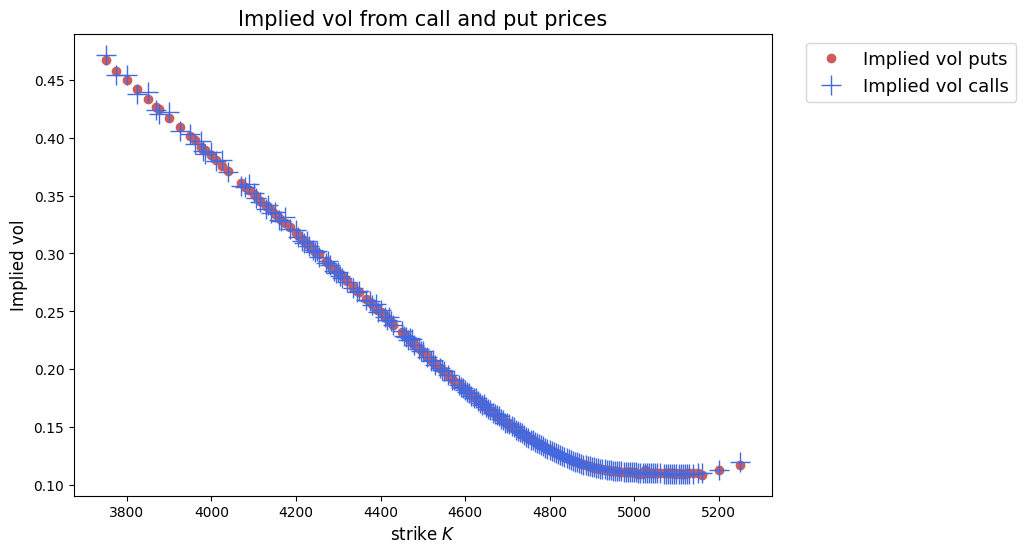

In [17]:
plt.figure(figsize=(9,6))

plt.plot(strikes, vols_puts,
        color='indianred', linewidth=0., marker=".", markersize=12, label="Implied vol puts")

plt.plot(strikes, vols_calls,
         color='royalblue', linewidth=0., marker="+", markersize=14, label="Implied vol calls")

plt.xlabel("strike $K$", fontsize=12)
plt.ylabel("Implied vol", fontsize=12)
plt.title("Implied vol from call and put prices", fontsize=15)

plt.legend(loc=9, fontsize=13, bbox_to_anchor=(1.2, 1.0), ncol=1)

$\blacktriangleright$ Plot the same implied volatility smile against the log-forward moneyness variable defined by
$$
k = \log(K / F_0^T),
$$ 
as opposed to the strike $K$.

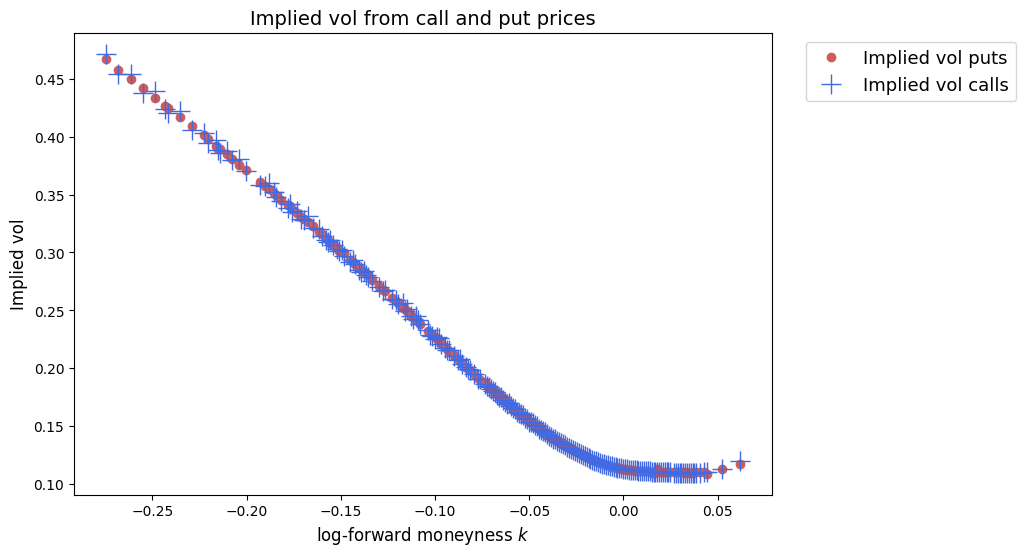

In [18]:
plt.figure(figsize=(9,6))

mkt_log_mon = np.log(strikes / F_T)

plt.plot(mkt_log_mon, vols_puts,
         color='indianred', linewidth=0., marker=".", markersize=12, label="Implied vol puts")

plt.plot(mkt_log_mon, vols_calls,
         color='royalblue', linewidth=0., marker="+", markersize=14, label="Implied vol calls")

plt.xlabel(r"log-forward moneyness $k$", fontsize=12)
plt.ylabel("Implied vol", fontsize=12)
plt.title("Implied vol from call and put prices", fontsize=14)

plt.legend(loc=9, fontsize=13, bbox_to_anchor=(1.2, 1.0), ncol=1)

Let us save the values of the log-moneyness and implied volatility we just computed into a dedicated csv file.

In [19]:
vol_data = np.array([mkt_log_mon, vols_calls])

np.savetxt("SPX_vol_quotes.csv", vol_data, delimiter=";")

$\blacktriangleright$ __Now also evaluate__ the SPX implied volatility smile from the call and put quotes for all strikes, using Netwon's method.

You can copy-paste the content of the appropriate cell above, and replace the bisection method with Newton's.

In [28]:
###########################
## Implied vol from puts
###########################
vols_puts = np.zeros(strikes.size)

for i in range(strikes.size):
    K = strikes[i]

    # Done.
    vol, iterations = volImplCore_Newton(
        tau=tau,
        K=K,
        DF=discount_factor,
        F=F_T,
        price=put_prices[i],  # type: ignore
        initial_point=0.2,
        price_tol=1.0e-4,
        max_iter=50,
        CallOrPutFlag=0,
    )

    vols_puts[i] = vol

############################
## Implied vol from calls
############################
vols_calls = np.zeros(strikes.size)

for i in range(strikes.size):
    K = strikes[i]

    # Done.
    vol, iterations = volImplCore_Newton(
        tau=tau,
        K=K,
        DF=discount_factor,
        F=F_T,
        price=call_prices[i],  # type: ignore
        initial_point=0.2,
        price_tol=1.0e-4,
        max_iter=50,
        CallOrPutFlag=1,
    )

    vols_calls[i] = vol

print("Done")

/home/raynor/Lectures/X/NPoFD/TPs/TP6*/BlackScholesFunctions.py:115: RuntimeWarning: divide by zero encountered in scalar divide
  vol = vol - (current_price - price) / Vega_core(tau, K, DF, F, vol)
/home/raynor/Lectures/X/NPoFD/TPs/TP6*/BlackScholesFunctions.py:20: RuntimeWarning: invalid value encountered in scalar subtract
  d_2 = d_1 - sigma_sqrt_tau
/home/raynor/Lectures/X/NPoFD/TPs/TP6*/BlackScholesFunctions.py:73: RuntimeWarning: overflow encountered in scalar power
  vega = DF * F * np.sqrt(tau) * np.exp(-d_1**2 / 2) / np.sqrt(2*np.pi)
/home/raynor/Lectures/X/NPoFD/TPs/TP6*/BlackScholesFunctions.py:41: RuntimeWarning: invalid value encountered in scalar subtract
  d_2 = d_1 - sigma_sqrt_tau


Done


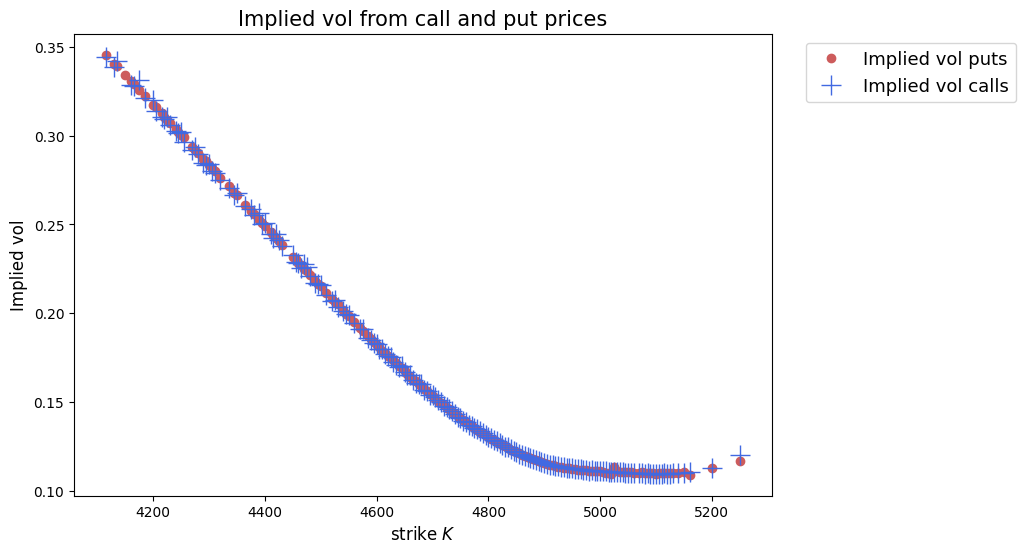

In [29]:
plt.figure(figsize=(9, 6))

plt.plot(
    strikes,
    vols_puts,
    color="indianred",
    linewidth=0.0,
    marker=".",
    markersize=12,
    label="Implied vol puts",
)

plt.plot(
    strikes,
    vols_calls,
    color="royalblue",
    linewidth=0.0,
    marker="+",
    markersize=14,
    label="Implied vol calls",
)

plt.xlabel("strike $K$", fontsize=12)
plt.ylabel("Implied vol", fontsize=12)
plt.title("Implied vol from call and put prices", fontsize=15)

plt.legend(loc=9, fontsize=13, bbox_to_anchor=(1.2, 1.0), ncol=1)

Has the computation of the option implied volatility by Newton's method succeded for every value of the strike $K$?

### __Other data sets__

The smile processing routine above can be applied to any set of option prices, among which:

+ Other option quotes on the SP500 index, or any other asset available on the [CBOE quotes platform](http://www.cboe.com/delayedquote/quote-table)

+ The option prices generated by a model

In [30]:
# Nope.